# Import

In [1]:
import os
import argparse
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models
from torchvision.models import (
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    efficientnet_b2, EfficientNet_B2_Weights,
    resnet50, ResNet50_Weights,
    resnet101, ResNet101_Weights,
)
from torchvision import transforms
from tqdm.auto import tqdm
import os
import numpy as np
from PIL import Image

# final image shape (W, H)
image_shape = (256, 128)

DATASET_PATH = "Dataset"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


# Data preprocessing

In [2]:
# -----------------------------
# 1) Class palette (GT colors)
# -----------------------------
CLASS_COLORS = [
    (0,   0,   0),     # class 0
    (0,  60,   0),     # class 1
    (0, 255,   0),     # class 2
    (102,102,  51),    # class 3
    (170,170, 170),    # class 4
    (0, 120, 255),     # class 5
]
NUM_CLASSES = len(CLASS_COLORS)
IGNORE = 255

COLOR_TO_ID = {c: i for i, c in enumerate(CLASS_COLORS)}

ID_TO_COLOR = np.array(CLASS_COLORS, dtype=np.uint8)  # (6,3)


# ---------------------------------------
# 2) Load images (RGB, depth_color, GT)
# ---------------------------------------
def load_the_image(path, image_shape):
    """Load RGB, depth_color, and GT_color images into numpy arrays."""
        
    rgb_dir = os.path.join(path,'rgb')
    gt_dir = os.path.join(path,'GT_color')
    depth_dir = os.path.join(path,'depth_color')
    filenames =sorted([f for f in os.listdir(rgb_dir) if f.lower().endswith(('.png'))])
    
    rgb_list = []
    gt_color_list = []
    depth_list = []

    for name in filenames:
        rgb_path = os.path.join(rgb_dir,name)
        depth_path = os.path.join(depth_dir,name)
        gt_path = os.path.join(gt_dir,name)

        img_rgb  = cv.imread(rgb_path)
        img_rgb = cv.cvtColor(img_rgb,cv.COLOR_BGR2RGB)
        img_rgb = cv.resize(img_rgb, image_shape)
        
        img_depth = cv.imread(depth_path)
        img_depth = cv.cvtColor(img_depth, cv.COLOR_BGR2RGB)
        img_depth = cv.resize(img_depth, image_shape)

        img_gt = cv.imread(gt_path)
        img_gt = cv.cvtColor(img_gt, cv.COLOR_BGR2RGB)
        img_gt = cv.resize(img_gt, image_shape, interpolation=cv.INTER_NEAREST)

        rgb_list.append(img_rgb)
        depth_list.append(img_depth)
        gt_color_list.append(img_gt)

    return np.array(rgb_list), np.array(depth_list), np.array(gt_color_list)

# ---------------------------------------
# 3) Convert GT RGB colors -> class IDs
# ---------------------------------------
def remap_mask_rgb_to_ids(mask_rgb):
    """
    mask_rgb: (H,W,3) uint8 with colors from CLASS_COLORS
    returns: (H,W) uint8 with values 0..5, and 255 for unknown
    """
    
        
    out = np.full(mask_rgb.shape[:2], IGNORE, dtype=np.uint8)
    
    for i, color in enumerate(CLASS_COLORS):
        
        match = np.all(mask_rgb == color, axis=-1)
        out[match] = i
        
        
    return out

# ---------------------------------------
# 4) Convert predicted IDs -> GT colors
# ---------------------------------------
def ids_to_color(mask_ids):
    """
    mask_ids: (H,W) int/uint
    returns: (H,W,3) uint8 colored with CLASS_COLORS; ignore=255 -> black
    """
    
        
    colored = np.zeros((mask_ids.shape[0], mask_ids.shape[1], 3), dtype=np.uint8)
    
    for i, color in enumerate(CLASS_COLORS):
        colored[mask_ids == i] = color
        
        
    return colored

def convert_prediction_from_logits(logits_chw):
    """
    logits_chw: numpy array (C,H,W)
    returns: (H,W,3) uint8 in the SAME palette as GT_color
    """
    
        
    pred_ids = np.argmax(logits_chw, axis=0)

        
    return ids_to_color(pred_ids)

# ---------------------------------------
# 5) Load dataset + build integer masks
# ---------------------------------------
train_rgb, train_depth, train_labels_color = load_the_image(f"{DATASET_PATH}/train", image_shape)
valid_rgb, valid_depth, valid_labels_color = load_the_image(f"{DATASET_PATH}/valid", image_shape)
test_rgb,  test_depth,  test_labels_color  = load_the_image(f"{DATASET_PATH}/test",  image_shape)


train_labels = np.stack([remap_mask_rgb_to_ids(m) for m in train_labels_color], axis=0)
valid_labels = np.stack([remap_mask_rgb_to_ids(m) for m in valid_labels_color], axis=0)
test_labels  = np.stack([remap_mask_rgb_to_ids(m) for m in test_labels_color],  axis=0)


# plot input

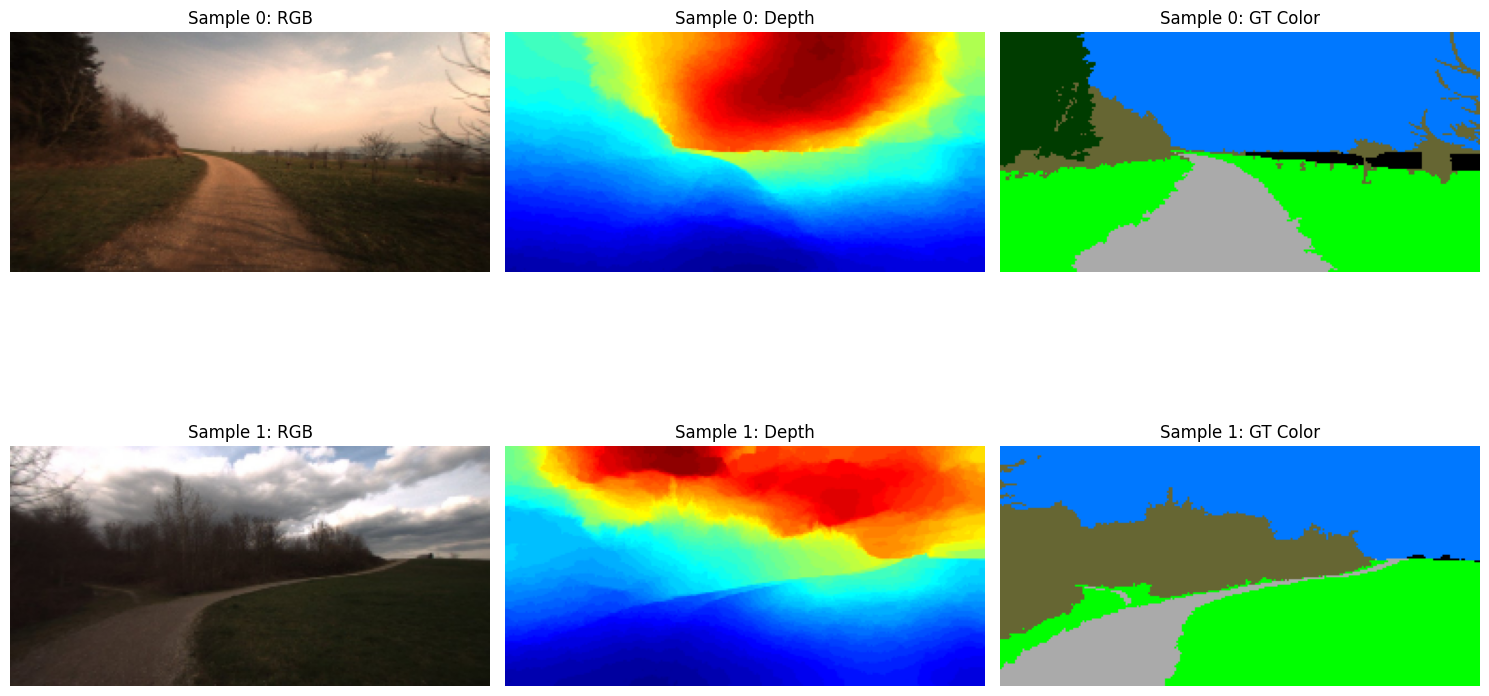

In [3]:
def visualize_preprocessing(rgb_batch, depth_batch, labels_batch, num_samples=2):
    plt.figure(figsize=(15, 5 * num_samples))
    
    for i in range(num_samples):
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(rgb_batch[i])
        plt.title(f"Sample {i}: RGB")
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(depth_batch[i])
        plt.title(f"Sample {i}: Depth")
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(labels_batch[i])
        plt.title(f"Sample {i}: GT Color")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_preprocessing(train_rgb, train_depth, train_labels_color, num_samples=2)

# Make Dataloader

In [4]:
class DualStreamArrayDataset(Dataset):
    def __init__(self, rgb_np, nir_np, mask_np):
        self.rgb = rgb_np
        self.nir = nir_np
        self.mask = mask_np

    
    def __len__(self):
        
        return len(self.rgb)

    def __getitem__(self, idx):
        
        rgb_img = self.rgb[idx]
        nir_img = self.nir[idx]
        mask_img = self.mask[idx]


        rgb = torch.from_numpy(rgb_img.transpose(2, 0, 1)).float() / 255.0
        nir = torch.from_numpy(nir_img.transpose(2, 0, 1)).float() / 255.0
        
        mask = torch.from_numpy(mask_img).long()

        return rgb, nir, mask


batch_size = 4

train_loader = DataLoader(DualStreamArrayDataset(train_rgb, train_depth, train_labels),
                          batch_size=batch_size, shuffle=True, num_workers=0)

valid_loader = DataLoader(DualStreamArrayDataset(valid_rgb, valid_depth, valid_labels),
                          batch_size=batch_size, shuffle=False, num_workers=0)

test_loader = DataLoader(DualStreamArrayDataset(test_rgb, test_depth, test_labels),
                         batch_size=batch_size, shuffle=False, num_workers=0)


# Dual Stream Model

In [5]:
class DualStreamSegNet(nn.Module):
    """
    Dual-stream semantic segmentation:
    backbone(rgb) + backbone(nir) -> concat -> head -> upsample to input size
    """

    def __init__(self, list_of_conv_layers, num_classes: int, backbone="MNV3", dropout=0.2):
        super().__init__()

        
        if backbone == "MNV3":
            self.backbone_rgb = models.mobilenet_v3_large(weights='DEFAULT').features
            self.backbone_nir = models.mobilenet_v3_large(weights='DEFAULT').features
            
            backbone_out_channels = 960 
        elif backbone == "RESNET50":
            
            resnet_rgb = models.resnet50(weights='DEFAULT')
            resnet_nir = models.resnet50(weights='DEFAULT')
            
            self.backbone_rgb = nn.Sequential(*list(resnet_rgb.children())[:-2])
            self.backbone_nir = nn.Sequential(*list(resnet_nir.children())[:-2])
            
            backbone_out_channels = 2048

        else:
            raise ValueError(f"Backbone {backbone} not supported in this template.")
        
        self.head = self._make_head(backbone_out_channels * 2, list_of_conv_layers, dropout=dropout)
        
        self.classifier = nn.Conv2d(list_of_conv_layers[-1], num_classes, kernel_size=1)
        

    def _make_head(self, in_ch, units, dropout=0.2):
        layers = []
        ch = in_ch
        for u in units:
            layers += [
                nn.Conv2d(ch, u, 3, padding=1, bias=False),
                nn.BatchNorm2d(u),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=dropout),
            ]
            ch = u
        return nn.Sequential(*layers)

    def forward(self, x_rgb, x_nir):

        feat_rgb = self.backbone_rgb(x_rgb)
        feat_nir = self.backbone_nir(x_nir)

        combined = torch.cat([feat_rgb, feat_nir], dim=1)
        x = self.head(combined)

        logits_small = self.classifier(x)

        logits = F.interpolate(logits_small, size=x_rgb.shape[2:], mode='bilinear', align_corners=False)
        
        return logits

# helper Functions

In [6]:
def pixel_accuracy(logits, mask):
    preds = torch.argmax(logits, dim=1)
    
    
    valid_mask = (mask != IGNORE)
    
    correct = (preds == mask) & valid_mask
    
    acc = correct.sum().float() / valid_mask.sum().float()
    
    return acc
        
       
class DiceLoss(nn.Module):
    
    def __init__(self, num_classes=6, ignore_index=255, smooth=1e-6):
        super(DiceLoss, self).__init__() 
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, logits, mask):
        probs = F.softmax(logits, dim=1)
        
        valid_mask = (mask != self.ignore_index).float()
        
        target_one_hot = F.one_hot(mask.clamp(min=0, max=self.num_classes-1), 
                                   num_classes=self.num_classes).permute(0, 3, 1, 2).float()
        
        valid_mask_exp = valid_mask.unsqueeze(1) 
        probs = probs * valid_mask_exp
        target_one_hot = target_one_hot * valid_mask_exp

        intersection = torch.sum(probs * target_one_hot, dim=(2, 3))
        union = torch.sum(probs, dim=(2, 3)) + torch.sum(target_one_hot, dim=(2, 3))

        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        
        return 1.0 - dice.mean()
        
    


# Defince run_epoch and Model Compile

In [7]:
loss_fn = DiceLoss(num_classes=6, ignore_index=255).to(device)

compiled_model = DualStreamSegNet(
    list_of_conv_layers=[128, 256,256],
    num_classes=6,
    backbone="RESNET50",  
).to(device)

def freeze_bn(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()
        for p in m.parameters():
            p.requires_grad = False

compiled_model.apply(freeze_bn)
optimizer = torch.optim.AdamW(compiled_model.parameters(), lr=1e-4, weight_decay=1e-4)
torch.nn.utils.clip_grad_norm_(compiled_model.parameters(), 1.0)


def run_epoch(model, loader, train=True, max_steps=None):
    if train:
        model.train()
    else:
        model.eval()

    
    
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for i, (rgb, nir, mask) in enumerate(loader):
        if max_steps is not None and i >= max_steps:
            break
        
        rgb, nir, mask = rgb.to(device), nir.to(device), mask.to(device)

        if train:
            optimizer.zero_grad() 
            logits = model(rgb, nir)
            loss = loss_fn(logits, mask)
            acc = pixel_accuracy(logits, mask)
            
            loss.backward() 
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step() 
        else:
            with torch.no_grad():
                logits = model(rgb, nir)
                loss = loss_fn(logits, mask)
                acc = pixel_accuracy(logits, mask)

        total_loss += loss.item()
        total_acc += acc.item()
        n_batches += 1
        

    return total_loss / max(n_batches, 1), total_acc / max(n_batches, 1)


# Run Model

In [8]:
num_epochs = 15
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    
    train_loss, train_acc = run_epoch(compiled_model, train_loader, train=True)
    
    val_loss, val_acc = run_epoch(compiled_model, valid_loader, train=False)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(compiled_model.state_dict(), "best_dual_stream_model.pth")
        save_msg = "(Best Model Saved!)"
    else:
        save_msg = ""

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} {save_msg}")

print("\nTraining Complete!")

compiled_model.load_state_dict(torch.load("best_dual_stream_model.pth"))

test_loss, test_acc = run_epoch(compiled_model, test_loader, train=False)

print("-" * 30)
print(f"FINAL TEST SET RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("-" * 30)



Starting training on cuda...
Epoch [1/15] Train Loss: 0.6569, Train Acc: 0.6518 | Val Loss: 0.5820, Val Acc: 0.7713 (Best Model Saved!)
Epoch [2/15] Train Loss: 0.5261, Train Acc: 0.7945 | Val Loss: 0.5194, Val Acc: 0.8224 (Best Model Saved!)
Epoch [3/15] Train Loss: 0.4850, Train Acc: 0.8392 | Val Loss: 0.4841, Val Acc: 0.8472 (Best Model Saved!)
Epoch [4/15] Train Loss: 0.4627, Train Acc: 0.8588 | Val Loss: 0.4753, Val Acc: 0.8538 (Best Model Saved!)
Epoch [5/15] Train Loss: 0.4502, Train Acc: 0.8720 | Val Loss: 0.4677, Val Acc: 0.8563 (Best Model Saved!)
Epoch [6/15] Train Loss: 0.4415, Train Acc: 0.8777 | Val Loss: 0.4612, Val Acc: 0.8611 (Best Model Saved!)
Epoch [7/15] Train Loss: 0.4343, Train Acc: 0.8844 | Val Loss: 0.4510, Val Acc: 0.8630 (Best Model Saved!)
Epoch [8/15] Train Loss: 0.4273, Train Acc: 0.8867 | Val Loss: 0.4438, Val Acc: 0.8668 (Best Model Saved!)
Epoch [9/15] Train Loss: 0.4199, Train Acc: 0.8919 | Val Loss: 0.4415, Val Acc: 0.8638 
Epoch [10/15] Train Loss: 0

# Show prediction

In [9]:
def convert_prediction_from_logits(logits_chw, number_of_classes, hight_of_pred_image=None, width_of_pred_image=None):
    """logits_chw: numpy array (C, H, W). Returns RGB (H, W, 3) with GT colors."""
    
    pred_ids = np.argmax(logits_chw, axis=0)
    
    result_holder = ids_to_color(pred_ids)
    
    if hight_of_pred_image is not None and width_of_pred_image is not None:
        result_holder = cv.resize(result_holder, (width_of_pred_image, hight_of_pred_image), 
                                  interpolation=cv.INTER_NEAREST)
    
    return result_holder


compiled_model.eval()

test_it = iter(test_loader)
batch_rgb, batch_nir, batch_mask = next(test_it)

with torch.no_grad():
    logits = compiled_model(batch_rgb.to(device), batch_nir.to(device))
    predictions = logits.cpu().numpy() 

disp_rgb = (batch_rgb.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)
disp_nir = (batch_nir.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)

disp_gt = np.array([ids_to_color(m.numpy()) for m in batch_mask])

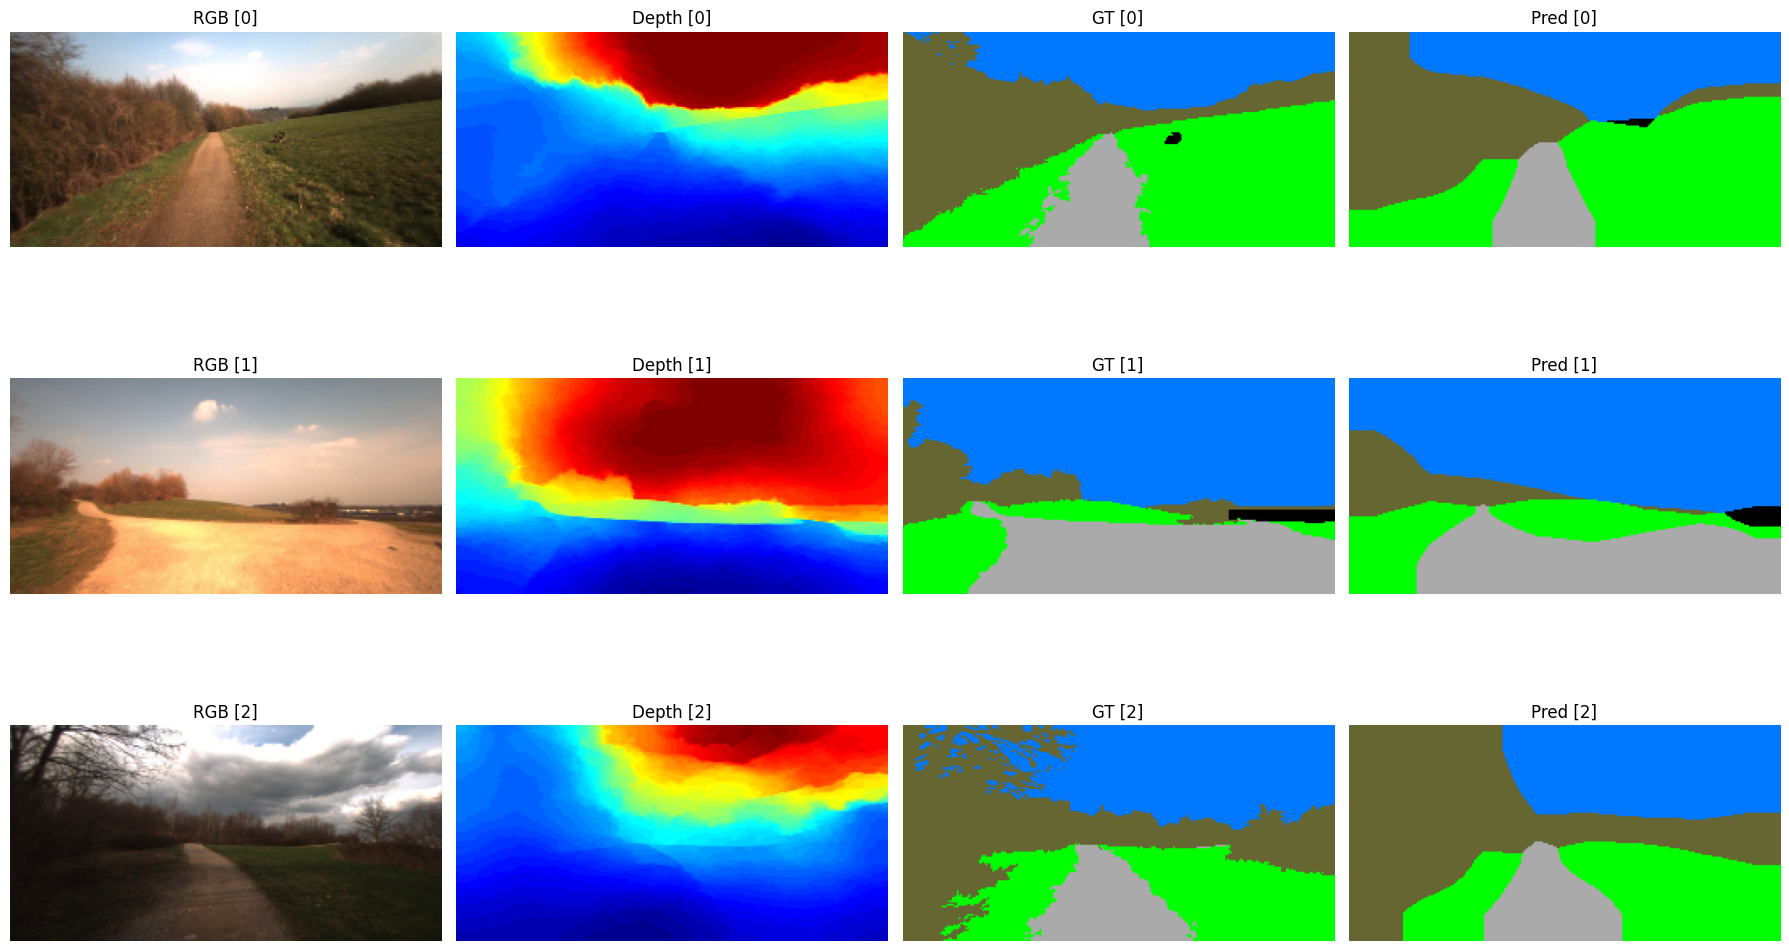

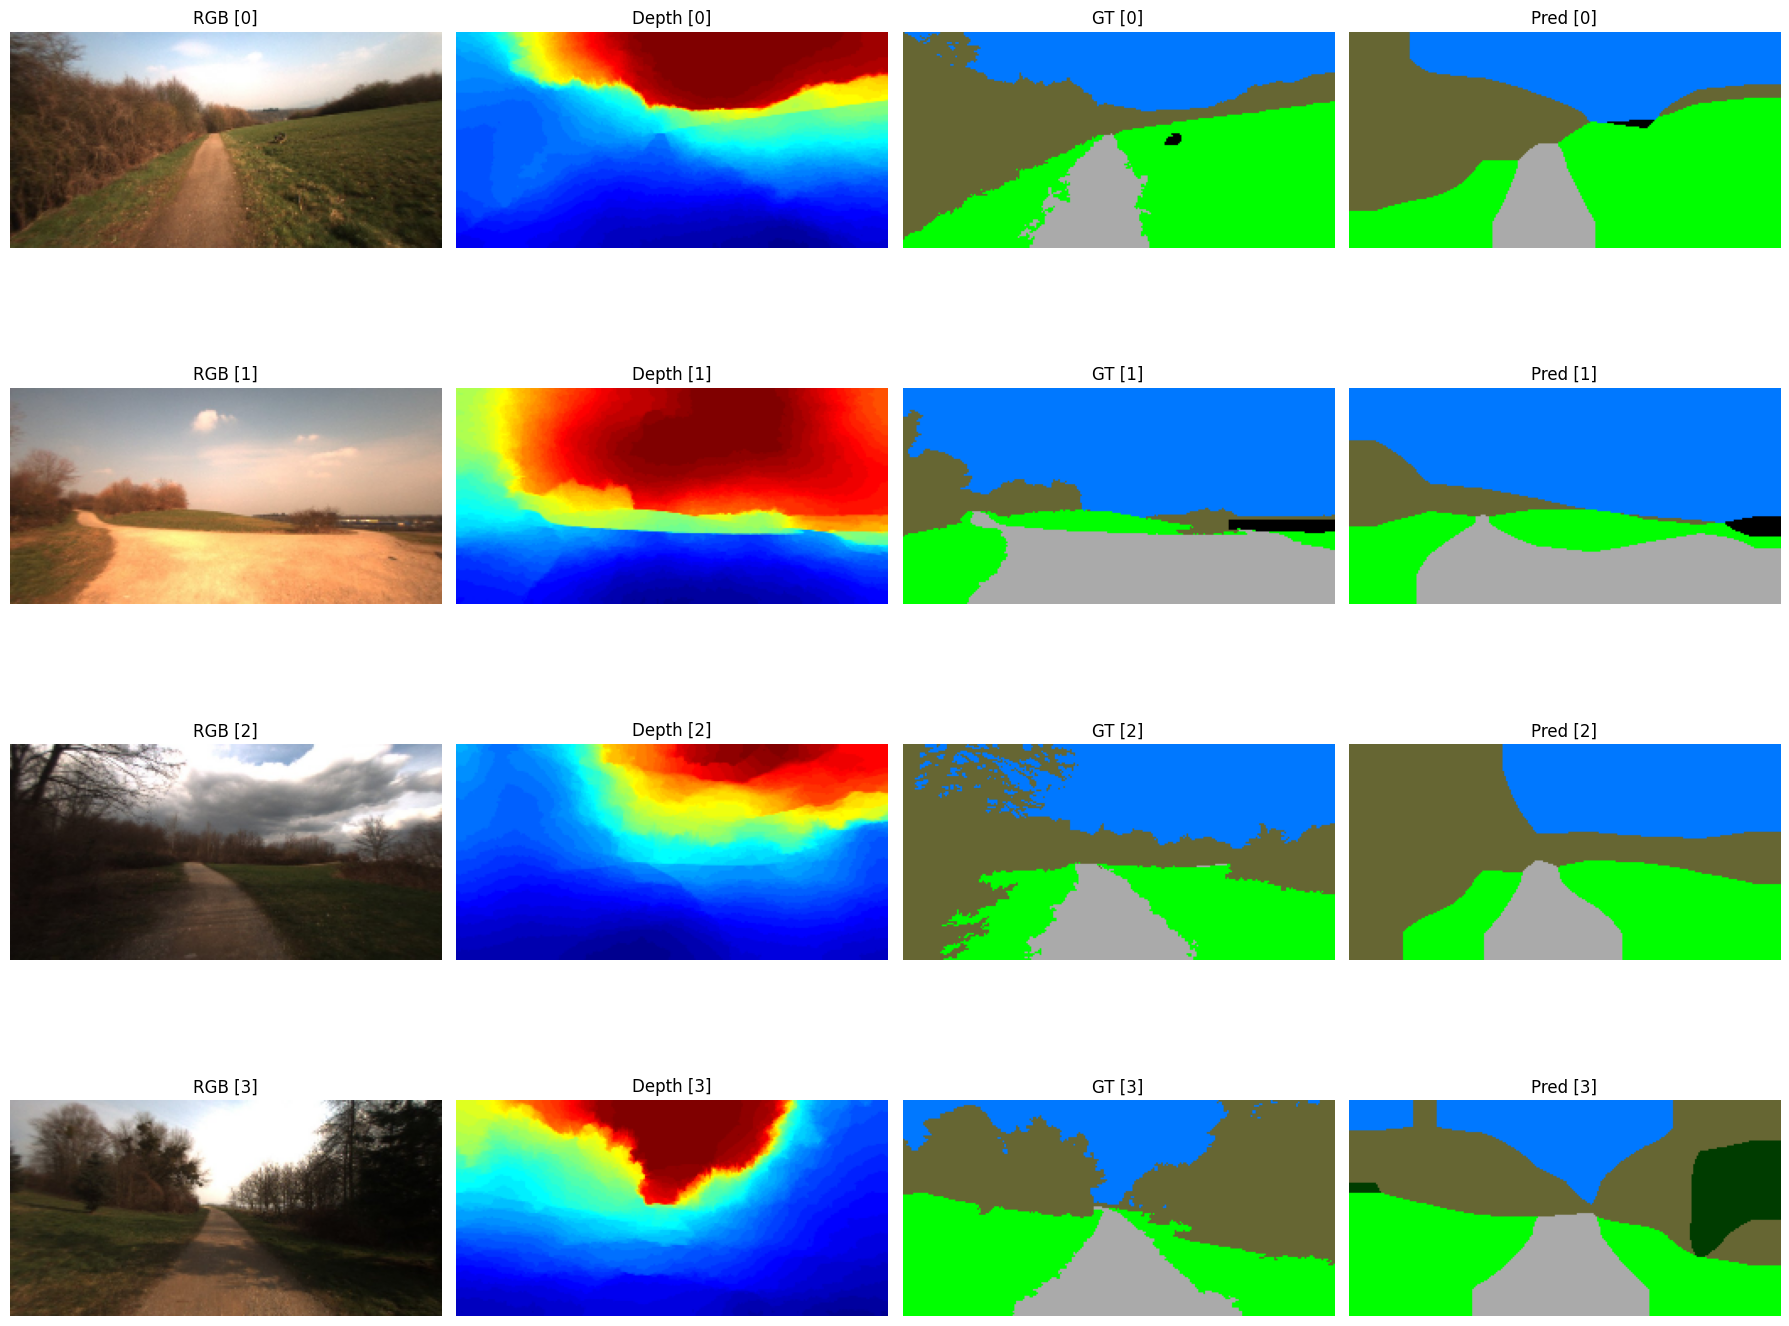

In [10]:
def show_comparison_rows(test_rgb, test_depth, test_labels_color, predictions, n=6, start=0, num_classes=6):
    N = predictions.shape[0]
    idxs = list(range(start, min(start + n, N)))

    plt.figure(figsize=(18, 3.8 * len(idxs)))

    for r, i in enumerate(idxs):
        pred_rgb = convert_prediction_from_logits(predictions[i], number_of_classes=num_classes) 

    
        ax = plt.subplot(len(idxs), 4, r * 4 + 1)
        ax.imshow(test_rgb[i].astype(np.uint8))
        ax.set_title(f"RGB [{i}]")
        ax.axis("off")

        ax = plt.subplot(len(idxs), 4, r * 4 + 2)
        ax.imshow(test_depth[i].astype(np.uint8))
        ax.set_title(f"Depth [{i}]")
        ax.axis("off")

        ax = plt.subplot(len(idxs), 4, r * 4 + 3)
        ax.imshow(test_labels_color[i].astype(np.uint8))
        ax.set_title(f"GT [{i}]")
        ax.axis("off")

        ax = plt.subplot(len(idxs), 4, r * 4 + 4)
        ax.imshow(pred_rgb)
        ax.set_title(f"Pred [{i}]")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_comparison_rows(test_rgb, test_depth, test_labels_color, predictions, n=3, start=0, num_classes=6)
show_comparison_rows(disp_rgb, disp_nir, disp_gt, predictions, n=4, num_classes=6)


# Single Stream

In [11]:
class SingleStreamSegNet(nn.Module):
    """
    Single-stream semantic segmentation:
    backbone(x) -> head -> classifier -> upsample to input size

    Keeps the same forward signature: forward(x_rgb, x_nir)
    so your existing run_epoch(model, loader, ...) still works.
    """

    def __init__(self, list_of_conv_layers, num_classes: int, backbone="RESNET50", stream="rgb", dropout=0.2):
        super().__init__()
        
        self.stream = stream

        if backbone == "MNV3":
            self.backbone = models.mobilenet_v3_large(weights='DEFAULT').features
            backbone_out_channels = 960

        elif backbone == "RESNET50":
            resnet = models.resnet50(weights='DEFAULT')
            self.backbone = nn.Sequential(*list(resnet.children())[:-2])
            backbone_out_channels = 2048


        self.head = self._make_head(backbone_out_channels, list_of_conv_layers, dropout=dropout)

        self.classifier = nn.Conv2d(list_of_conv_layers[-1], num_classes, kernel_size=1)

    def _make_head(self, in_ch, units, dropout=0.2):
        layers = []
        ch = in_ch
        for u in units:
            layers += [
                nn.Conv2d(ch, u, 3, padding=1, bias=False),
                nn.BatchNorm2d(u),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=dropout),
            ]
            ch = u
        return nn.Sequential(*layers)

    def forward(self, x_rgb, x_nir):
        
        if self.stream == "rgb":
            x = x_rgb
        else:
            x = x_nir

        feat = self.backbone(x)

        x = self.head(feat)

        logits_small = self.classifier(x)

        logits = F.interpolate(logits_small, size=x_rgb.shape[2:], mode='bilinear', align_corners=False)

        return logits

In [12]:
compiled_model = SingleStreamSegNet(
    list_of_conv_layers=[128, 256, 256],
    num_classes=6,
    backbone="RESNET50",
    stream="rgb"
).to(device)

compiled_model.apply(freeze_bn)
optimizer = torch.optim.AdamW(compiled_model.parameters(), lr=1e-4, weight_decay=1e-4)
torch.nn.utils.clip_grad_norm_(compiled_model.parameters(), 1.0)

tensor(0.)

In [13]:
# Get results on test set
num_epochs = 15
best_val_acc = 0.0
history_single = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print(f"Starting training on {device}")

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(compiled_model, train_loader, train=True)
    val_loss, val_acc = run_epoch(compiled_model, valid_loader, train=False)
    
    history_single["train_loss"].append(train_loss)
    history_single["train_acc"].append(train_acc)
    history_single["val_loss"].append(val_loss)
    history_single["val_acc"].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(compiled_model.state_dict(), "best_single_stream_rgb_model.pth")
        save_msg = "(Best Model Saved!)"
    else:
        save_msg = ""

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} {save_msg}")

print("\nTraining Complete!")

test_loss, test_acc = run_epoch(compiled_model, test_loader, train=False)

print("-" * 30)
print(f"FINAL TEST SET RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("-" * 30)


Starting training on cuda
Epoch [1/15] Train Loss: 0.6578, Train Acc: 0.6493 | Val Loss: 0.5786, Val Acc: 0.7406 (Best Model Saved!)
Epoch [2/15] Train Loss: 0.5349, Train Acc: 0.7772 | Val Loss: 0.5242, Val Acc: 0.8130 (Best Model Saved!)
Epoch [3/15] Train Loss: 0.4905, Train Acc: 0.8297 | Val Loss: 0.5002, Val Acc: 0.8391 (Best Model Saved!)
Epoch [4/15] Train Loss: 0.4674, Train Acc: 0.8547 | Val Loss: 0.4814, Val Acc: 0.8472 (Best Model Saved!)
Epoch [5/15] Train Loss: 0.4564, Train Acc: 0.8639 | Val Loss: 0.4729, Val Acc: 0.8577 (Best Model Saved!)
Epoch [6/15] Train Loss: 0.4479, Train Acc: 0.8718 | Val Loss: 0.4668, Val Acc: 0.8571 
Epoch [7/15] Train Loss: 0.4396, Train Acc: 0.8804 | Val Loss: 0.4578, Val Acc: 0.8652 (Best Model Saved!)
Epoch [8/15] Train Loss: 0.4336, Train Acc: 0.8848 | Val Loss: 0.4570, Val Acc: 0.8676 (Best Model Saved!)
Epoch [9/15] Train Loss: 0.4285, Train Acc: 0.8894 | Val Loss: 0.4461, Val Acc: 0.8707 (Best Model Saved!)
Epoch [10/15] Train Loss: 0.42

In [14]:
compiled_model.load_state_dict(torch.load("best_single_stream_rgb_model.pth"))
test_loss, test_acc = run_epoch(compiled_model, test_loader, train=False)

print("-" * 30)
print(f"FINAL TEST SET RESULTS (Single Stream RGB)")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("-" * 30)

------------------------------
FINAL TEST SET RESULTS (Single Stream RGB)
Test Loss: 0.4500
Test Accuracy: 0.8777
------------------------------


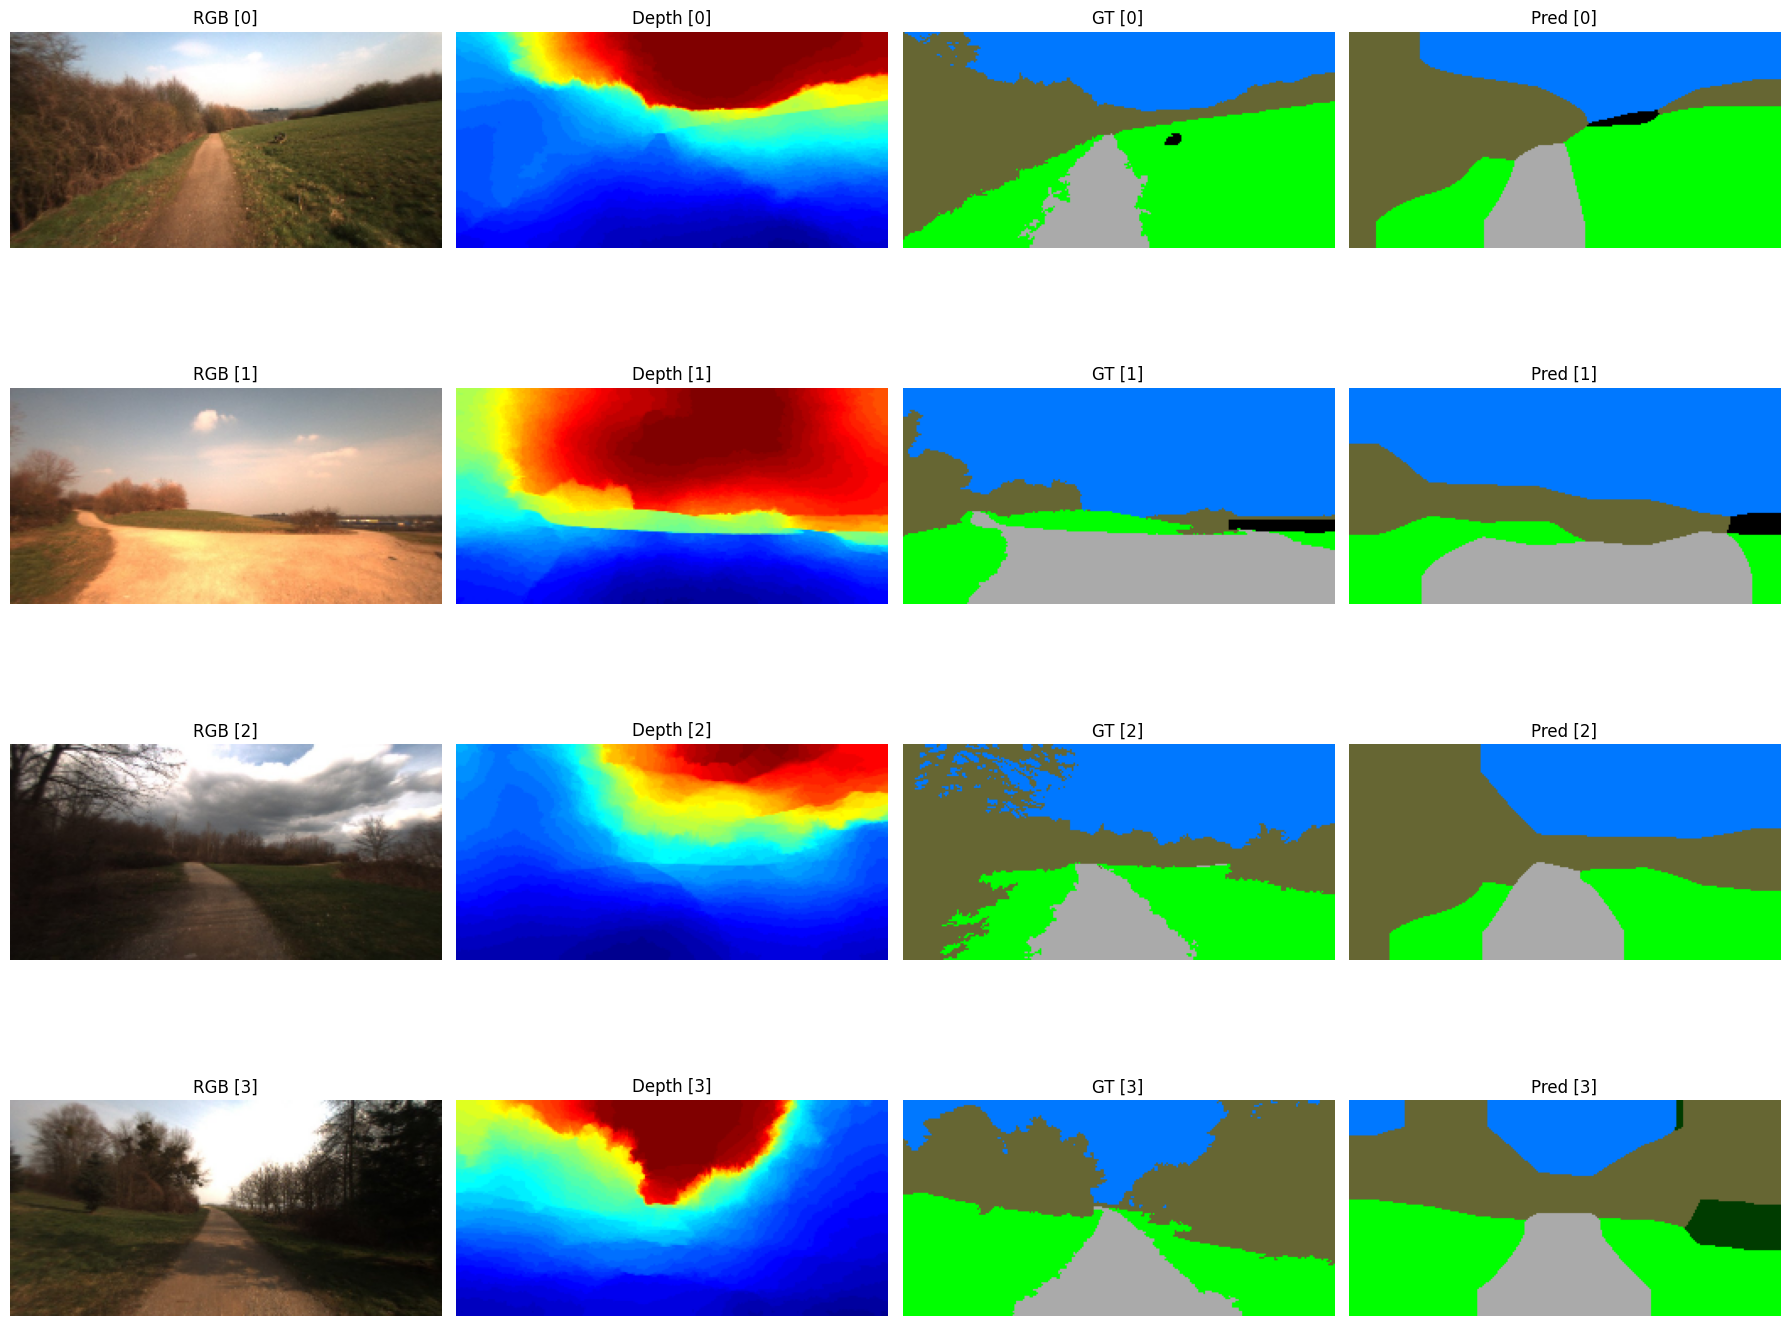

In [15]:

compiled_model.eval()

test_it = iter(test_loader)
batch_rgb, batch_nir, batch_mask = next(test_it)

with torch.no_grad():
    logits = compiled_model(batch_rgb.to(device), batch_nir.to(device))
    predictions = logits.cpu().numpy()

disp_rgb = (batch_rgb.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)
disp_nir = (batch_nir.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)
disp_gt = np.array([ids_to_color(m.numpy()) for m in batch_mask])

show_comparison_rows(disp_rgb, disp_nir, disp_gt, predictions, n=4, num_classes=6)


# Depth Model

In [16]:
compiled_model = SingleStreamSegNet(
    list_of_conv_layers=[128, 256, 256],
    num_classes=6,
    backbone="RESNET50",
    stream="nir"  
).to(device)

compiled_model.apply(freeze_bn)
optimizer = torch.optim.AdamW(compiled_model.parameters(), lr=1e-4, weight_decay=1e-4)
torch.nn.utils.clip_grad_norm_(compiled_model.parameters(), 1.0)

tensor(0.)

Epoch [1/15] Train Loss: 0.6728, Train Acc: 0.6196 | Val Loss: 0.5792, Val Acc: 0.7171 (Best Model Saved!)
Epoch [2/15] Train Loss: 0.5574, Train Acc: 0.7335 | Val Loss: 0.5467, Val Acc: 0.7734 (Best Model Saved!)
Epoch [3/15] Train Loss: 0.5123, Train Acc: 0.7925 | Val Loss: 0.5125, Val Acc: 0.7946 (Best Model Saved!)
Epoch [4/15] Train Loss: 0.4866, Train Acc: 0.8201 | Val Loss: 0.5096, Val Acc: 0.7998 (Best Model Saved!)
Epoch [5/15] Train Loss: 0.4675, Train Acc: 0.8435 | Val Loss: 0.4913, Val Acc: 0.8237 (Best Model Saved!)
Epoch [6/15] Train Loss: 0.4596, Train Acc: 0.8527 | Val Loss: 0.4819, Val Acc: 0.8239 (Best Model Saved!)
Epoch [7/15] Train Loss: 0.4494, Train Acc: 0.8644 | Val Loss: 0.4814, Val Acc: 0.8271 (Best Model Saved!)
Epoch [8/15] Train Loss: 0.4413, Train Acc: 0.8733 | Val Loss: 0.4714, Val Acc: 0.8395 (Best Model Saved!)
Epoch [9/15] Train Loss: 0.4353, Train Acc: 0.8780 | Val Loss: 0.4737, Val Acc: 0.8325 
Epoch [10/15] Train Loss: 0.4308, Train Acc: 0.8831 | Va

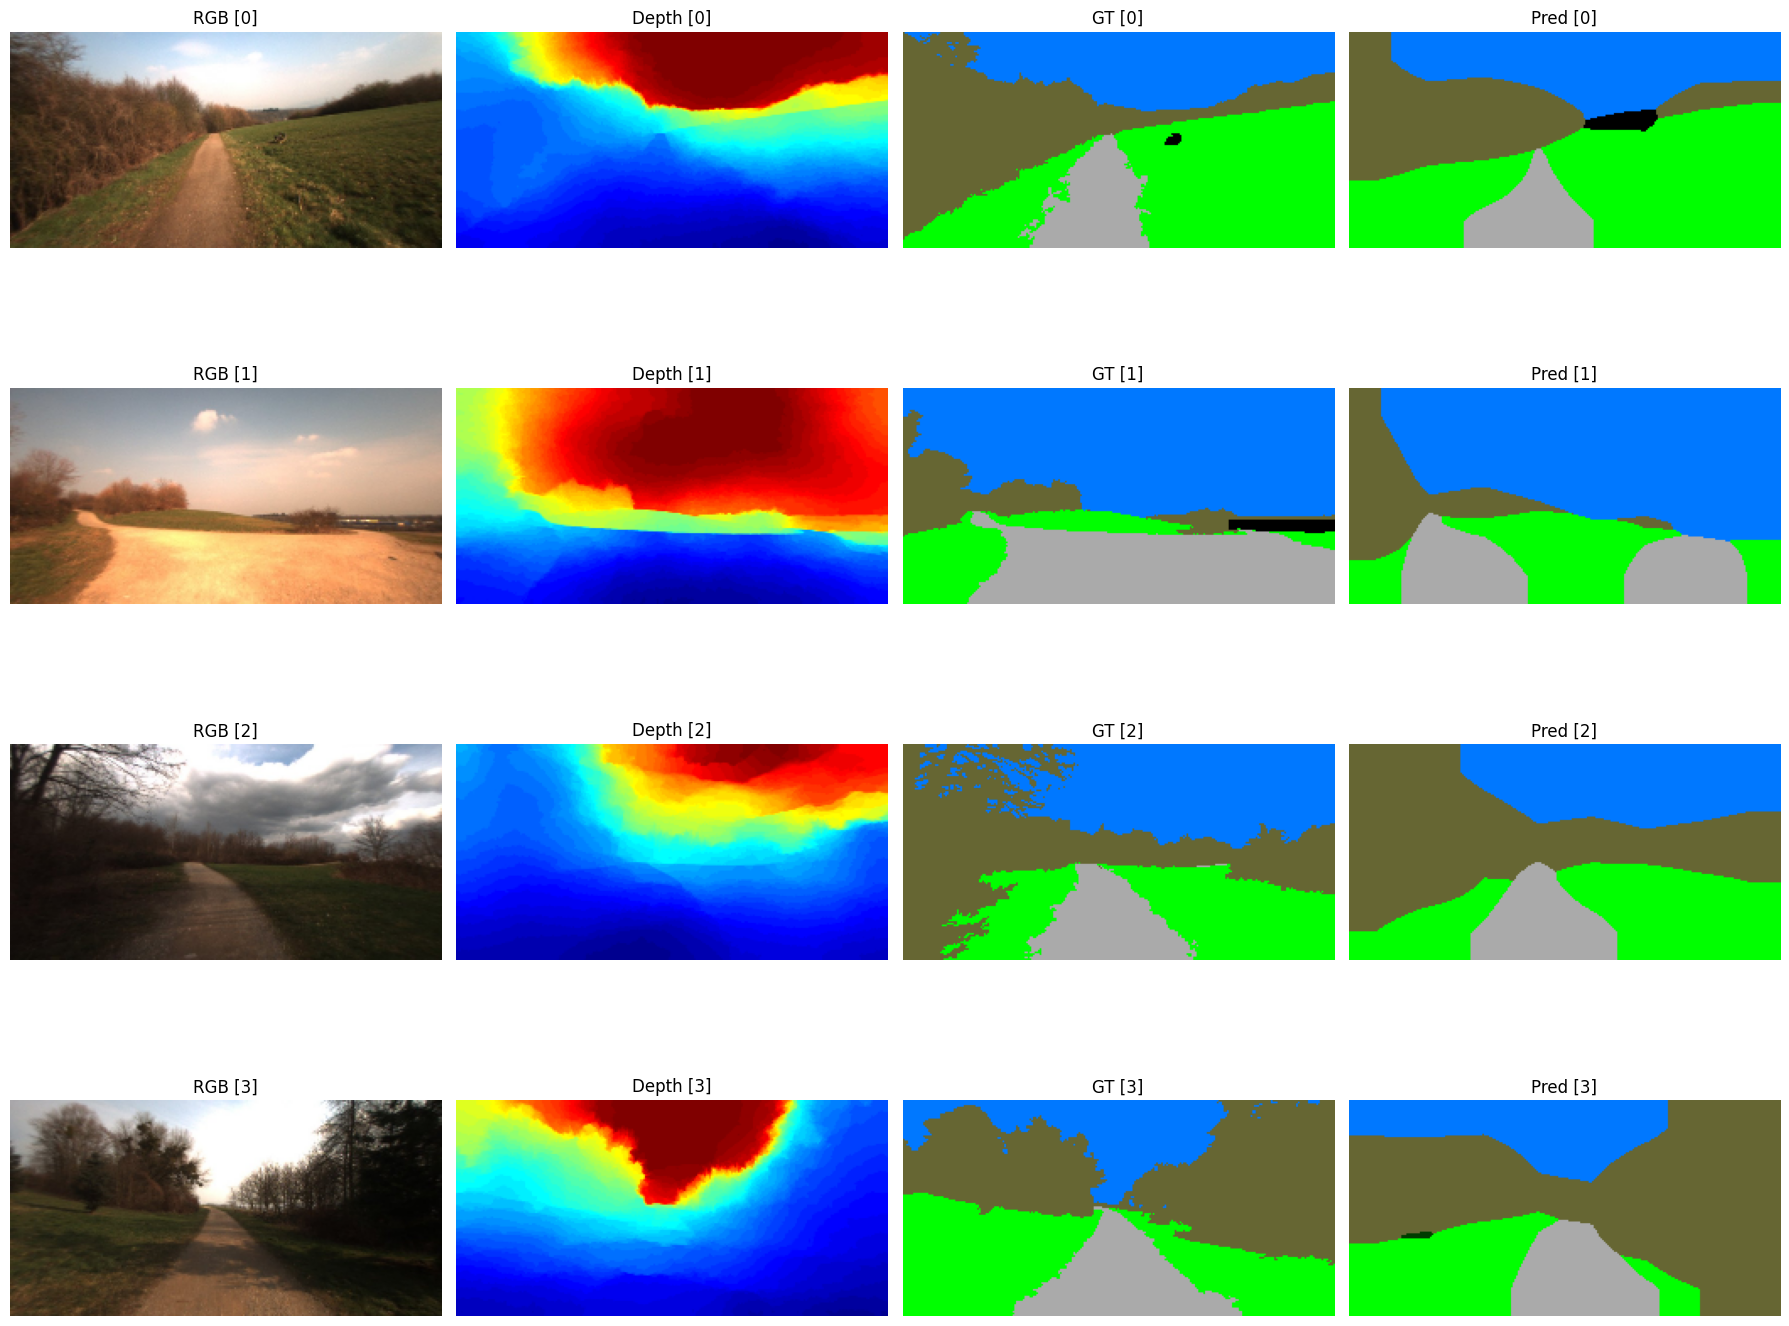

In [17]:
num_epochs = 15
best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(compiled_model, train_loader, train=True)
    val_loss, val_acc = run_epoch(compiled_model, valid_loader, train=False)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(compiled_model.state_dict(), "best_single_stream_depth_model.pth")
        save_msg = "(Best Model Saved!)"
    else:
        save_msg = ""

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} {save_msg}")

print("\nTraining Complete!")

# Test evaluation
compiled_model.load_state_dict(torch.load("best_single_stream_depth_model.pth"))
test_loss, test_acc = run_epoch(compiled_model, test_loader, train=False)

print("-" * 30)
print(f"FINAL TEST SET RESULTS (Single Stream Depth)")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("-" * 30)

# Visualization
compiled_model.eval()
test_it = iter(test_loader)
batch_rgb, batch_nir, batch_mask = next(test_it)

with torch.no_grad():
    logits = compiled_model(batch_rgb.to(device), batch_nir.to(device))
    predictions = logits.cpu().numpy()

disp_rgb = (batch_rgb.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)
disp_nir = (batch_nir.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)
disp_gt = np.array([ids_to_color(m.numpy()) for m in batch_mask])

show_comparison_rows(disp_rgb, disp_nir, disp_gt, predictions, n=4, num_classes=6)

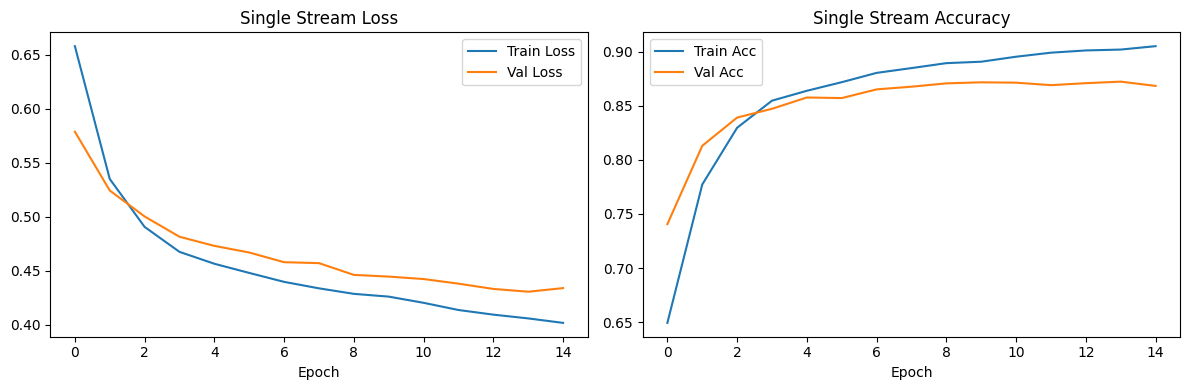

In [ ]:
# Ploting training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_single["train_loss"], label="Train Loss")
plt.plot(history_single["val_loss"], label="Val Loss")
plt.title("Single Stream Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_single["train_acc"], label="Train Acc")
plt.plot(history_single["val_acc"], label="Val Acc")
plt.title("Single Stream Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

# Compare results table

| Model                | Best Val Accuracy | Test Accuracy |
|----------------------|------------------|--------------|
| Dual (RGB + NIR)     | 87.48            | 87.73     |
| RGB Only             | 86.84           | 87.38      |
| NIR / Depth Only     | 84.82           | 84.66      |

## Conclusion

So, in this assignment we trained three models and compared there results for semantic segmentation using sensor fusion. At first, we used a dual stream model (RGB + Depth) where the test accuracy was 87.55. then we only used the RGB and got 87.77 as test accuracy. lastly, the depth only model got us 83.93 test accuracy. The results show that RGB Only and Dual Stream performed very similarly (87.73% vs 87.38%), while Depth Only performed slightly worse (84.66%). So here, the RGB information already captures most of the useful features. The depth information adds limited additional value, possibly because the dataset is small. However, the Depth Only model performing worse means that depth alone is not enough for proper segmentation.